# Exercise 0 : Ring attractors in 1d

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

## Mexican hat weight calculation and plot

In [82]:
def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    return A_exc*np.exp(-x**2/sigma_exc**2) - A_inh*np.exp(-x**2/sigma_inh**2)

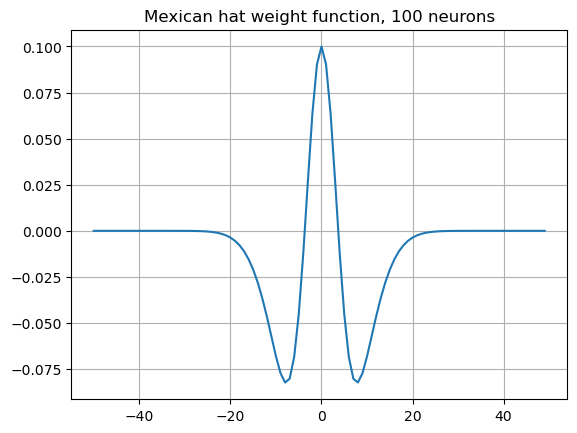

In [83]:
A_exc = 0.3
sigma_exc = 5.0
A_inh = 0.2
sigma_inh = 10.0

M = 100

xVals = np.arange(-M/2, M/2, 1)


w = mexican_hat_1d(xVals, A_exc, sigma_exc, A_inh, sigma_inh)


plt.plot(xVals, w)
plt.title("Mexican hat weight function, 100 neurons")
plt.grid()
plt.show()

## Using forward euler for an initial 1D solution

In [84]:
def ds_1D(s):
    r_vals = np.maximum(0, s)
    I_vals = scipy.ndimage.convolve1d(r_vals, w, mode='wrap')
    B = 1
    return 1/tau * (-s + I_vals + B)

In [85]:
def forward_euler(ds, s0, tSpan, dt):
    t = np.arange(tSpan[0], tSpan[1] + dt/100, dt)
    s = np.zeros((len(t), len(s0)))
    s[0] = s0

    for i in range(1, len(t)):
        s[i] = s[i-1] + dt * ds(s[i-1])
    
    return s, t


In [86]:
tau = 10e-3
s0 = np.random.uniform(0,0.1, M)

s, t  = forward_euler(ds_1D, s0, tSpan=[0, 500e-3], dt = 1e-3)
firing_rates = np.maximum(s, 0)


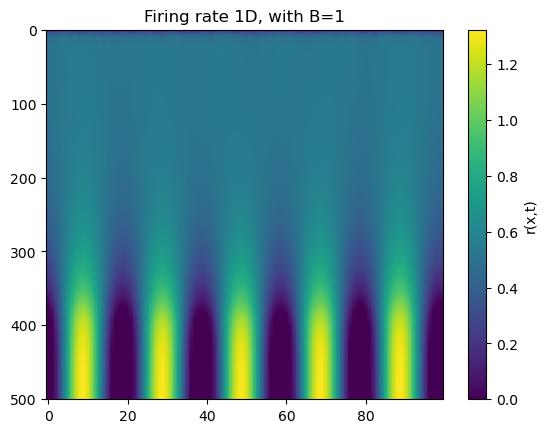

In [87]:
fig, ax = plt.subplots()
im = ax.imshow(firing_rates[:,:], aspect='auto')
fig.colorbar(im, label = 'r(x,t)')
plt.title("Firing rate 1D, with B=1")
plt.show()

## Testing for various seeds

In [88]:
import matplotlib.animation as animation
from IPython.display import HTML

In [89]:
fig, ax = plt.subplots()
ims = []

for i in range(3):
    np.random.seed(42*i)
    s0 = np.random.uniform(0,0.1, M)
    s, t  = forward_euler(ds_1D, s0, [0, 500e-3], dt = 1e-3)
    im = ax.imshow(s, aspect = 'auto', animated=True)

    if i == 0:
        ax.imshow(s, aspect='auto')  # show an initial one first
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True,
                                repeat_delay=1000)

plt.title("Animation of various seeds")
plt.close()  # Prevents static image from showing
HTML(ani.to_jshtml())

# Exercise 1 : 1D Velocity integration

1.1. Write a simulation class or function for this 2-population integrator. Use the previous parameters,
but set B0 = 1.5, α= 0.5, and weight shift l = 1.0. Run the simulation for 1000 ms with a timestep of
1 ms. For the first 300 ms, set v = 0 to let the activity pattern stabilize, and you should observe stable
bumps. From t= 300 ms to 700 ms, apply a constant velocity v = 1.0. For t>700 ms, v = 0. Plot the
sum of the firing rates rtotal(x,t) = rR(x,t) + rL(x,t) over time.

In [90]:
l = 1

wL = np.zeros(M)
wL[:-l] = w[l:]
wL[-l:] = w[:l]

wR = np.zeros(M)
wR[:l] = w[-l:]
wR[l:] = w[:-l]

wD = np.zeros((2,M))
wD[0] = wR
wD[1] = wL

In [91]:
B0 = 1.5
alpha = 0.5

def ds_2Pop_1(s, t):

    ds_vals = np.zeros(s.shape)

    I_vals = scipy.ndimage.convolve1d(np.maximum(s[0],0), wD[0], mode='wrap') + scipy.ndimage.convolve1d(np.maximum(s[1],0), wD[1], mode='wrap') 
    
    B = np.array([
        B0*(1+alpha*1*(t>300e-3)*(t<700e-3)),
        B0*(1-alpha*1*(t>300e-3)*(t<700e-3))
    ])
    ds_vals[0] = 1/tau * (-s[0] + I_vals + B[0])
    ds_vals[1] = 1/tau * (-s[1] + I_vals + B[1])

    return ds_vals

In [92]:
def two_pop_solver(ds, s0, tSpan, dt):

    t = np.arange(tSpan[0], tSpan[1] + dt/100, dt)
    s = np.zeros((2, len(t), M))
    s[0,0,:] = s0[0]
    s[1,0,:] = s0[1]


    for i in range(1, len(t)):
        s[:,i] = s[:, i-1] + dt * ds(s[:,i-1], t[i-1])

    r_sol = np.sum(np.maximum(0,s), axis=0)
    return r_sol

In [93]:
s0 = np.random.uniform(0,0.1, (2,M))

r_sol = two_pop_solver(ds_2Pop_1, s0, tSpan = [0, 1000e-3], dt = 1e-3)

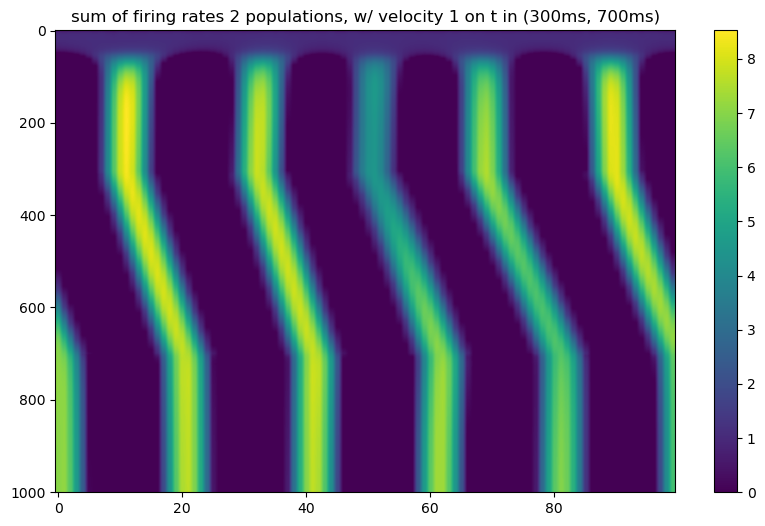

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.imshow(r_sol, aspect='auto')
plt.title("sum of firing rates 2 populations, w/ velocity 1 on t in (300ms, 700ms)")
plt.colorbar()
plt.show()

# Testing for varying velocities

In [95]:
B0 = 1.5
alpha = 0.5

vels1 = np.linspace(-2, -0.5, 5)
vels2 = np.linspace(0.5, 2, 5)
vels = np.zeros(11)

vels[0]=0
vels[1:6]=vels1
vels[6:]=vels2

def ds_2Pop_2(s, t):

    ds_vals = np.zeros(s.shape)

    I_vals = scipy.ndimage.convolve1d(np.maximum(s[0],0), wD[0], mode='wrap') + scipy.ndimage.convolve1d(np.maximum(s[1],0), wD[1], mode='wrap') 
    
    B = np.array([
        B0*(1+alpha*vels[int(t//300e-3)]),
        B0*(1-alpha*vels[int(t//300e-3)])
    ])
    ds_vals[0] = 1/tau * (-s[0] + I_vals + B[0])
    ds_vals[1] = 1/tau * (-s[1] + I_vals + B[1])

    return ds_vals

In [96]:
s0 = np.random.uniform(0,0.1, (2,M))

r_vels = two_pop_solver(ds_2Pop_2, s0, tSpan = [0, len(vels)*300e-3], dt = 1e-3)

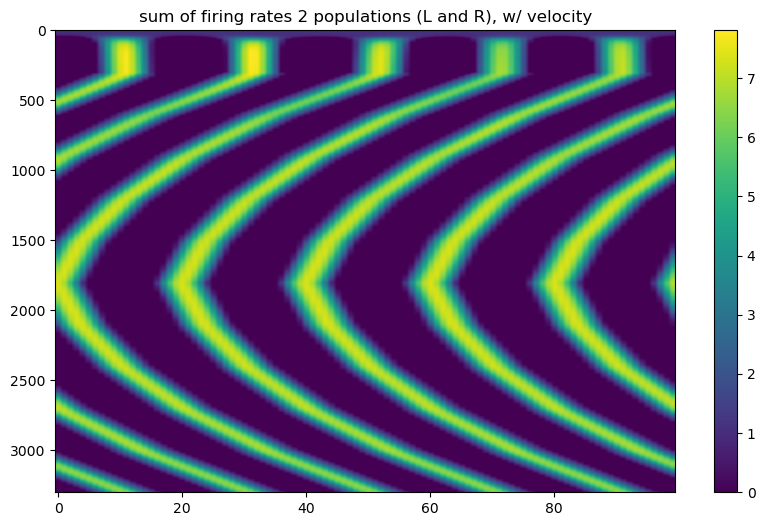

In [97]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.imshow(r_vels, aspect='auto')
plt.title("sum of firing rates 2 populations (L and R), w/ velocity")
plt.colorbar()
plt.show()

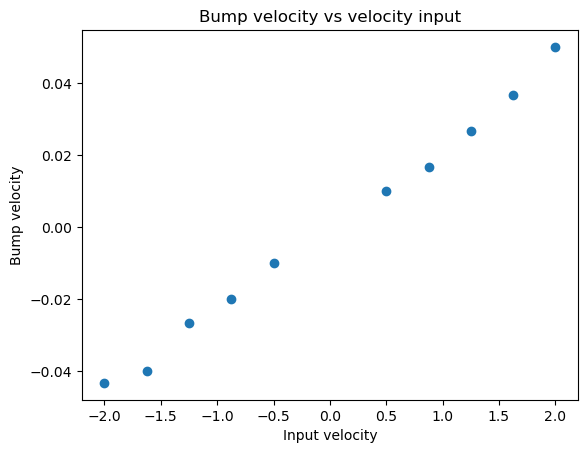

In [98]:
d_ind = np.zeros(11)

for i in range(0, 3300, 300):
    k0 = np.argmax(r_vels[i, 20:80]) + 20
    k1 = k0
    steps = 6
    for j in range(steps):
        k1 = np.argmax(r_vels[i+j*int(300//steps), k1-5:k1+5]) + k1 - 5
    d_ind[i//300] = k1 - k0

v_bump = d_ind/300
plt.scatter(vels[1:], v_bump[1:]) 
plt.title("Bump velocity vs velocity input")
plt.xlabel("Input velocity")
plt.ylabel("Bump velocity")
plt.show()